In [66]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# Data Collection

In [67]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "1h", 
    days = 1825,
    limit = 1000
)
df = data_collector.collect_data()

In [68]:
df.head()

,timestamp,open,high,low,close,volume
0,2020-11-06 04:00:00,15431.23,15583.95,15419.32,15548.50,4313.255303
1,2020-11-06 05:00:00,15548.50,15699.43,15482.01,15628.88,4839.600937
2,2020-11-06 06:00:00,15628.89,15757.59,15628.88,15679.76,4240.707168
3,2020-11-06 07:00:00,15679.77,15783.62,15657.50,15733.30,3866.897354
4,2020-11-06 08:00:00,15731.56,15739.00,15447.71,15479.24,5614.516150


In [69]:
df.tail()

,timestamp,open,high,low,close,volume
43775,2025-11-04 23:00:00,101295.70,101740.00,100907.36,101497.22,1518.90709
43776,2025-11-05 00:00:00,101497.23,101752.96,100350.00,100564.30,1452.38181
43777,2025-11-05 01:00:00,100564.30,101015.01,98966.80,100761.62,3025.00486
43778,2025-11-05 02:00:00,100761.62,101922.98,100754.54,101677.93,3700.99085
43779,2025-11-05 03:00:00,101677.94,102272.23,101461.98,102106.47,2555.03479


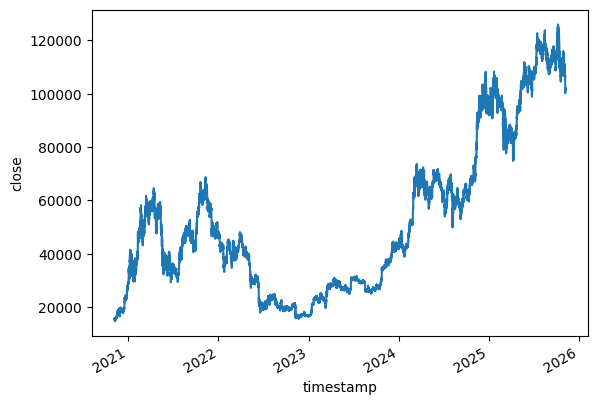

In [70]:
sns.lineplot(x="timestamp", y="close", data=df)
plt.gcf().autofmt_xdate()
plt.show()

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43780 entries, 0 to 43779
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  43780 non-null  datetime64[ns]
 1   open       43780 non-null  float64       
 2   high       43780 non-null  float64       
 3   low        43780 non-null  float64       
 4   close      43780 non-null  float64       
 5   volume     43780 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 2.0 MB


In [72]:
df.describe()

,timestamp,open,high,low,close,volume
count,43780,43780.000000,43780.000000,43780.000000,43780.000000,43780.000000
mean,2023-05-07 23:20:11.320237568,52172.593779,52379.902872,51956.432604,52174.574299,3193.524179
min,2020-11-06 04:00:00,14643.520000,14855.000000,14344.220000,14643.520000,0.000000
25%,2022-02-05 23:45:00,28087.747500,28212.340000,27978.825000,28088.980000,793.912772
50%,2023-05-08 01:30:00,43668.610000,43848.075000,43487.160000,43668.970000,1574.707379
75%,2024-08-06 02:15:00,66485.235000,66721.230000,66221.425000,66487.290000,3489.105467
max,2025-11-05 03:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600
std,NaN,29266.125393,29339.628787,29190.789573,29266.571343,4725.006588


# Technical Indicators

### Momentum

In [73]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [74]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [75]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [76]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

# Data Cleaning

In [77]:
dataset = df.copy()
data_cleaning = DataCleaning()
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

In [78]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-11-07 20:00:00,14643.52,14949.00,14344.22,14852.26,12190.569450,-426.256853,15129.200385,-1.036244,-0.520425,...,63.117511,-158.872769,-79.348910,-79.523859,25.590902,15296.487143,0.672534,1.176475,-0.503941,15173.166571
41,2020-11-07 21:00:00,14852.27,14937.69,14746.80,14822.58,4768.110335,-488.770941,15079.673167,-1.144487,-0.502934,...,61.396475,-175.036615,-98.486451,-76.550164,25.858443,15252.070714,0.811457,1.167189,-0.355731,15109.978952
42,2020-11-07 22:00:00,14822.58,14855.00,14662.16,14800.00,3303.886698,-575.885088,15033.745160,-1.228966,-0.469930,...,60.349150,-187.507131,-116.290587,-71.216544,26.007346,15202.195714,0.797138,1.193321,-0.396182,15049.702857
43,2020-11-07 23:00:00,14800.01,14918.00,14788.00,14818.30,2857.519938,-584.658441,15000.843648,-1.272141,-0.410484,...,59.729218,-193.680816,-131.768633,-61.912183,26.057869,15154.666429,0.819371,1.170389,-0.351018,14998.516762
44,2020-11-08 00:00:00,14818.30,14917.85,14703.88,14912.74,3545.030798,-563.191029,14994.659502,-1.241816,-0.304128,...,60.720880,-188.776885,-143.170284,-45.606601,26.094288,15109.020714,0.804314,1.175845,-0.371531,14966.259905


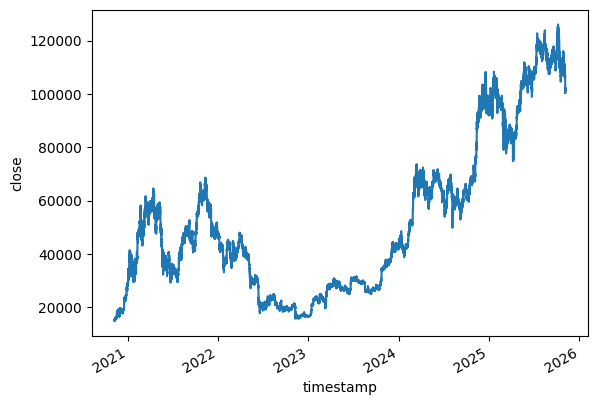

In [79]:
sns.lineplot(x="timestamp", y="close", data=dataset)
plt.gcf().autofmt_xdate()
plt.show()

In [80]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-11-07 20:00:00,14643.52,14949.00,14344.22,14852.26,12190.569450,-426.256853,15129.200385,-1.036244,-0.520425,...,63.117511,-158.872769,-79.348910,-79.523859,25.590902,15296.487143,0.672534,1.176475,-0.503941,15173.166571
41,2020-11-07 21:00:00,14852.27,14937.69,14746.80,14822.58,4768.110335,-488.770941,15079.673167,-1.144487,-0.502934,...,61.396475,-175.036615,-98.486451,-76.550164,25.858443,15252.070714,0.811457,1.167189,-0.355731,15109.978952
42,2020-11-07 22:00:00,14822.58,14855.00,14662.16,14800.00,3303.886698,-575.885088,15033.745160,-1.228966,-0.469930,...,60.349150,-187.507131,-116.290587,-71.216544,26.007346,15202.195714,0.797138,1.193321,-0.396182,15049.702857
43,2020-11-07 23:00:00,14800.01,14918.00,14788.00,14818.30,2857.519938,-584.658441,15000.843648,-1.272141,-0.410484,...,59.729218,-193.680816,-131.768633,-61.912183,26.057869,15154.666429,0.819371,1.170389,-0.351018,14998.516762
44,2020-11-08 00:00:00,14818.30,14917.85,14703.88,14912.74,3545.030798,-563.191029,14994.659502,-1.241816,-0.304128,...,60.720880,-188.776885,-143.170284,-45.606601,26.094288,15109.020714,0.804314,1.175845,-0.371531,14966.259905


# Feature Engineering

### Timestamp Features

In [81]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

In [82]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
43775,2025-11-04 23:00:00,101295.70,101740.00,100907.36,101497.22,1518.90709,-3907.705853,102309.472127,-1.449387,-0.099752,...,1.133647,-0.285680,101661.904381,23,1,4,11,2025,308,4
43776,2025-11-05 00:00:00,101497.23,101752.96,100350.00,100564.30,1452.38181,-3710.007824,102040.957899,-1.454424,-0.083832,...,1.124865,-0.297552,101421.773619,0,2,4,11,2025,309,5
43777,2025-11-05 01:00:00,100564.30,101015.01,98966.80,100761.62,3025.00486,-3582.619765,101922.786320,-1.426739,-0.044918,...,1.184456,-0.425163,101238.924476,1,2,4,11,2025,309,5
43778,2025-11-05 02:00:00,100761.62,101922.98,100754.54,101677.93,3700.99085,-3153.819676,101919.158332,-1.317156,0.051733,...,1.133449,-0.285306,101214.660857,2,2,4,11,2025,309,5
43779,2025-11-05 03:00:00,101677.94,102272.23,101461.98,102106.47,2555.03479,-2822.244441,101924.916899,-1.182705,0.148947,...,1.096216,-0.199391,101269.198857,3,2,4,11,2025,309,5


In [83]:
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

# Feature Selection

In [84]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [85]:
dataset = dataset.sort_values('timestamp')

In [86]:
X_close = dataset.drop(['timestamp', 'close'], axis=1)
y_close = dataset['close']

### Feature Importance

In [87]:
xgb_close = XGBRegressor(
    device='cuda',
    max_bin=256,
    eval_metric='rmse',
)

In [88]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [89]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum


### Get most value variables

In [90]:
features_by_target = {}
fold_metrics, oof_pred, gain_accum = model_training(X_close, y_close, xgb_close, tscv)
importance_df = (
    gain_accum.div(100)             # average gain across folds
    .sort_values(ascending=False)
    .rename("avg_gain")
    .reset_index()
    .rename(columns={"index": "feature"})
)
importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100
features_by_target["close"] = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()

In [91]:
features_by_target

{'close': ['high',
  'low',
  'DONCHIAN_HIGH',
  'DONCHIAN_LOW',
  'KELTNER_HIGH',
  'KAMA',
  'VWAP',
  'WMA',
  'DONCHIAN_MIDDLE',
  'ADI',
  'BBANDS_LOWER',
  'BBANDS_HIGH']}

In [92]:
all_features = features_by_target["close"] + ["close"]

### Save Selected Features

In [93]:
import os
import json
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)

In [94]:
with open('feature_selection/features_by_target_1h_lstm.json', 'w') as f:
    json.dump(features_by_target, f, indent=4)

# Scale Data

In [95]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [96]:
dataset.set_index('timestamp', inplace=True)

In [97]:
#dataset.drop(['timestamp'], axis=1, inplace=True)

In [98]:
dataset.head()

,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-11-07 20:00:00,14643.52,14949.00,14344.22,14852.26,12190.569450,-426.256853,15129.200385,-1.036244,-0.520425,-0.515819,...,1.176475,-0.503941,15173.166571,20,5,4,11,2020,312,7
2020-11-07 21:00:00,14852.27,14937.69,14746.80,14822.58,4768.110335,-488.770941,15079.673167,-1.144487,-0.502934,-0.641553,...,1.167189,-0.355731,15109.978952,21,5,4,11,2020,312,7
2020-11-07 22:00:00,14822.58,14855.00,14662.16,14800.00,3303.886698,-575.885088,15033.745160,-1.228966,-0.469930,-0.759035,...,1.193321,-0.396182,15049.702857,22,5,4,11,2020,312,7
2020-11-07 23:00:00,14800.01,14918.00,14788.00,14818.30,2857.519938,-584.658441,15000.843648,-1.272141,-0.410484,-0.861656,...,1.170389,-0.351018,14998.516762,23,5,4,11,2020,312,7
2020-11-08 00:00:00,14818.30,14917.85,14703.88,14912.74,3545.030798,-563.191029,14994.659502,-1.241816,-0.304128,-0.937688,...,1.175845,-0.371531,14966.259905,0,6,4,11,2020,313,8


### Spliting Data

In [99]:
train_size = int(len(dataset) * 0.7)
val_size = int(len(dataset) * 0.15)

In [100]:
train_data = dataset.iloc[:train_size]
val_data = dataset.iloc[train_size:train_size + val_size]
test_data = dataset.iloc[train_size + val_size:]

In [101]:
train_data.shape, val_data.shape, test_data.shape

((30598, 78), (6556, 78), (6558, 78))

### Scaling Data

In [102]:
scaler_X = StandardScaler()

In [103]:
scaler_X.fit(train_data[features_by_target["close"]])

StandardScaler()

In [104]:
X_train_scaled = scaler_X.transform(train_data[features_by_target["close"]])
X_val_scaled   = scaler_X.transform(val_data[features_by_target["close"]])
X_test_scaled  = scaler_X.transform(test_data[features_by_target["close"]])

In [105]:
X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape

((30598, 12), (6556, 12), (6558, 12))

In [106]:
scaler_y = StandardScaler()

In [107]:
scaler_y.fit(train_data[["close"]])

StandardScaler()

In [108]:

y_train_scaled = scaler_y.transform(train_data[["close"]]).flatten()
y_val_scaled   = scaler_y.transform(val_data[["close"]]).flatten()
y_test_scaled  = scaler_y.transform(test_data[["close"]]).flatten()

In [109]:
y_train_scaled.shape, y_val_scaled.shape, y_test_scaled.shape

((30598,), (6556,), (6558,))

# Window Creation 

In [110]:
def create_lstm_windows(X_df, y_series, window_size: int, horizon: int = 1):
    Xs, ys = [], []
    X_values = X_df.values
    y_values = y_series.values

    for i in range(len(X_df) - window_size - horizon + 1):
        Xs.append(X_values[i:(i + window_size)])
        ys.append(y_values[i + window_size + horizon - 1])

    return np.array(Xs), np.array(ys)

In [111]:
train_scaled_df = pd.DataFrame(X_train_scaled, columns=features_by_target["close"])
val_scaled_df   = pd.DataFrame(X_val_scaled, columns=features_by_target["close"])
test_scaled_df  = pd.DataFrame(X_test_scaled, columns=features_by_target["close"])

In [166]:
X_train, y_train = create_lstm_windows(train_scaled_df, pd.Series(y_train_scaled), 15, 1)
X_val, y_val     = create_lstm_windows(val_scaled_df, pd.Series(y_val_scaled), 15, 1)
X_test, y_test   = create_lstm_windows(test_scaled_df, pd.Series(y_test_scaled), 15, 1)

In [167]:
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (30583, 15, 12) (30583,)
Val: (6541, 15, 12) (6541,)
Test: (6543, 15, 12) (6543,)


# LSTM Models

In [168]:

import keras
from keras.models import Sequential
from keras.layers import Input, Dense, LSTM, Dropout, Bidirectional
from keras.optimizers import Adam

In [169]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(50, return_sequences= True, ),
    LSTM(64, return_sequences= False),
    Dense(32),
    Dense(16),
    Dense(1)
])
model.compile(optimizer= Adam(learning_rate=0.001), loss= 'mse' , metrics=['mean_absolute_error'])

In [170]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 15, 50)         │        12,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,665 (174.47 KB)

 Trainable params: 44,665 (174.47 KB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [171]:
from keras.callbacks import EarlyStopping

In [172]:
# Fitting the LSTM to the Training set
callbacks = [EarlyStopping(monitor= 'val_loss', patience= 20 , restore_best_weights= True)]
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs= 100, batch_size= 32 , callbacks= callbacks )

Epoch 1/100
956/956 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0085 - mean_absolute_error: 0.0450 - val_loss: 0.3696 - val_mean_absolute_error: 0.3636
Epoch 2/100
956/956 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0017 - mean_absolute_error: 0.0286 - val_loss: 0.1997 - val_mean_absolute_error: 0.2717
Epoch 3/100
956/956 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0012 - mean_absolute_error: 0.0241 - val_loss: 0.1128 - val_mean_absolute_error: 0.2032
Epoch 4/100
956/956 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 9.6117e-04 - mean_absolute_error: 0.0212 - val_loss: 0.1170 - val_mean_absolute_error: 0.2106
Epoch 5/100
956/956 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.7186e-04 - mean_absolute_error: 0.0204 - val_loss: 0.0928 - val_mean_absolute_error: 0.1837
Epoch 6/100
956/956 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 7.4664e-04 - mean_absolute_error: 0.0187 - val_loss: 0.0892 - val_mean_absolute_error: 0.1786
Epoch 7/100
956/956 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 7.7883e-04 - mean_ab

# Model Evaluation

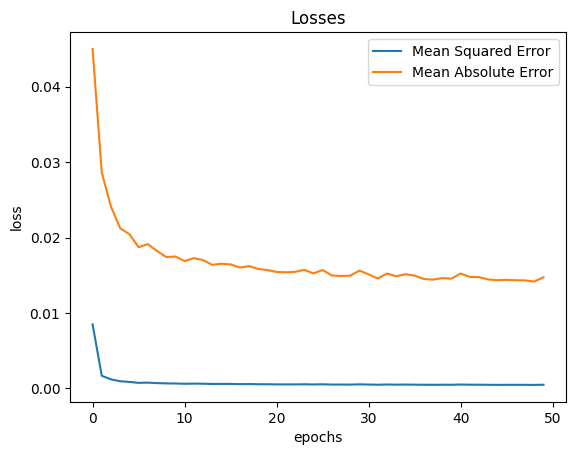

In [173]:
plt.plot(history.history["loss"])
plt.plot(history.history["mean_absolute_error"])
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

# Prediction

In [174]:
#inverse y_test scaling
y_pred_scaled = model.predict(X_test)

205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [175]:
y_pred_scaled.shape

(6543, 1)

In [176]:
y_test.shape, y_pred_scaled.shape

((6543,), (6543, 1))

In [177]:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [178]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 7997.7798


In [179]:
train = dataset.iloc[:train_size]
val = dataset.iloc[train_size:train_size + val_size]
test = dataset.iloc[train_size+val_size + 15:]

test = test.copy()  # para evitar el famoso Warning de pandas
test['Predictions'] = y_pred

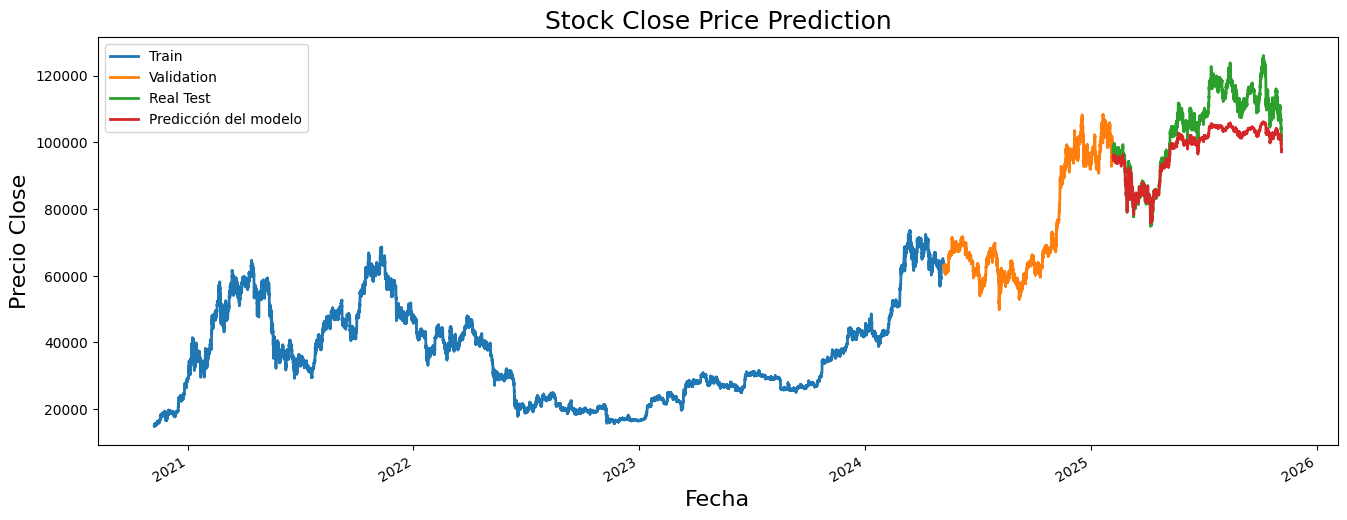

In [180]:
plt.figure(figsize=(16,6))
plt.title('Stock Close Price Prediction', fontsize=18)
plt.xlabel('Fecha', fontsize=16)
plt.ylabel('Precio Close', fontsize=16)

plt.plot(train.index, train['close'], linewidth=2)
plt.plot(val.index, val['close'], linewidth=2)
plt.plot(test.index, test['close'], linewidth=2)
plt.plot(test.index, test['Predictions'], linewidth=2)

plt.legend(['Train', 'Validation', 'Real Test', 'Predicción del modelo'])
plt.gcf().autofmt_xdate()
plt.show()

# Predict next 24 hours

In [181]:
from datetime import timedelta

In [182]:
def insert_end(Xin, new_input):
    timestep = 60
    for i in range(timestep - 1):
        Xin[:, i, :] = Xin[:, i+1, :]
    Xin[:, timestep - 1, :] = new_input
    return Xin

In [183]:
df["timestamp"] = pd.to_datetime(df["timestamp"])  # ensure correct type
last_time = df["timestamp"].iloc[-1]

In [185]:
future = 30
forecast = []
Xin = X_test[-1:, :, :]
time = []

for i in range(future):
    out = model.predict(Xin, batch_size=5)
    forecast.append(out[0,0])

    new_step = Xin[:, -1, :].copy()
    new_step[:,0] = out[0,0]
    Xin = insert_end(Xin, new_step)

    time.append(last_time + timedelta(hours=i))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


IndexError: index 15 is out of bounds for axis 1 with size 15

In [ ]:
time

[Timestamp('2025-11-03 03:00:00'),
 Timestamp('2025-11-03 04:00:00'),
 Timestamp('2025-11-03 05:00:00'),
 Timestamp('2025-11-03 06:00:00'),
 Timestamp('2025-11-03 07:00:00'),
 Timestamp('2025-11-03 08:00:00'),
 Timestamp('2025-11-03 09:00:00'),
 Timestamp('2025-11-03 10:00:00'),
 Timestamp('2025-11-03 11:00:00'),
 Timestamp('2025-11-03 12:00:00'),
 Timestamp('2025-11-03 13:00:00'),
 Timestamp('2025-11-03 14:00:00'),
 Timestamp('2025-11-03 15:00:00'),
 Timestamp('2025-11-03 16:00:00'),
 Timestamp('2025-11-03 17:00:00'),
 Timestamp('2025-11-03 18:00:00'),
 Timestamp('2025-11-03 19:00:00'),
 Timestamp('2025-11-03 20:00:00'),
 Timestamp('2025-11-03 21:00:00'),
 Timestamp('2025-11-03 22:00:00'),
 Timestamp('2025-11-03 23:00:00'),
 Timestamp('2025-11-04 00:00:00'),
 Timestamp('2025-11-04 01:00:00'),
 Timestamp('2025-11-04 02:00:00'),
 Timestamp('2025-11-04 03:00:00'),
 Timestamp('2025-11-04 04:00:00'),
 Timestamp('2025-11-04 05:00:00'),
 Timestamp('2025-11-04 06:00:00'),
 Timestamp('2025-11-

# Create Dataframe

In [ ]:
# Convert to array
forecast = np.array(forecast).reshape(-1,1)

# Inverse transform Close only
future_temp = np.zeros((future, x_test.shape[2]))
future_temp[:,0] = forecast[:,0]
forecast_real = scaler.inverse_transform(future_temp)[:,0]

print("Forecasted Closing Prices:")
print(forecast_real)

Forecasted Closing Prices:
[101535.14279728 101535.1532793  101535.16376133 101535.17074934
 101535.18472537 101535.18821938 101535.1987014  101535.1952074
 101535.1987014  101535.22665347 101535.22665347 101535.22665347
 101535.24761751 101535.2406295  101535.24761751 101535.25460553
 101535.26508755 101535.26508755 101535.27556958 101535.27556958
 101535.2860516  101535.2860516  101535.2860516  101535.2860516
 101535.29653362 101535.30352164 101535.31050966 101535.30701565
 101535.31749767 101535.31050966]


In [ ]:
forcasted_output = pd.DataFrame(forecast_real)
date = pd.DataFrame(time)
df_result = pd.concat([date,forcasted_output], axis=1)
df_result.columns = "Date", "Forecasted"

In [ ]:
df_result.set_index("Date", inplace=True)

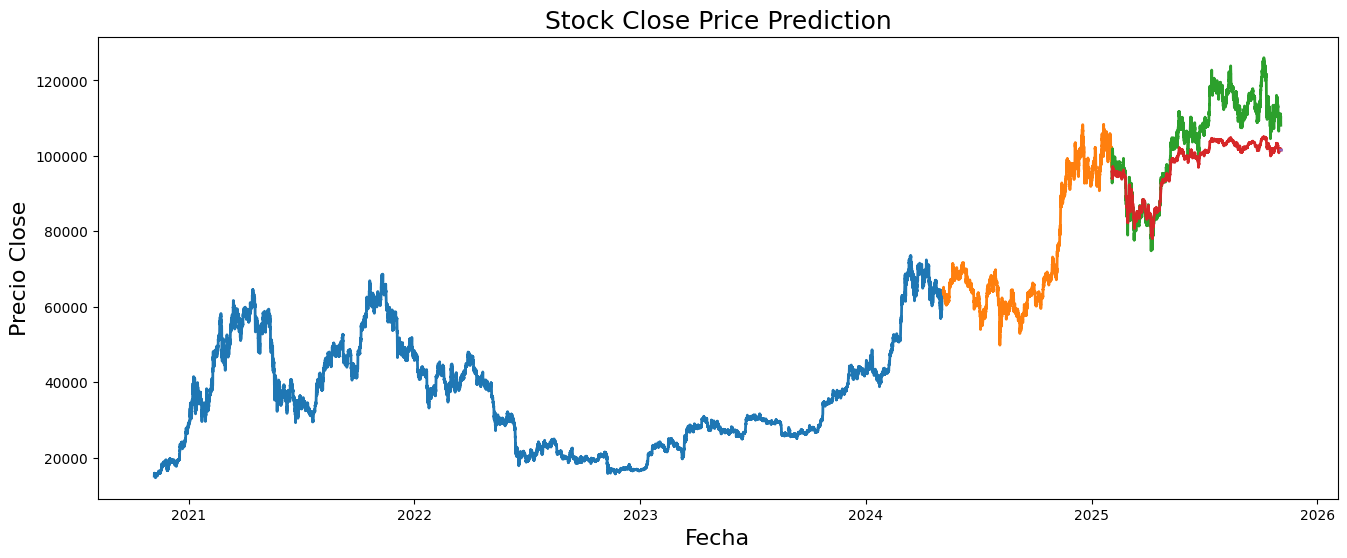

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Stock Close Price Prediction', fontsize=18)
plt.xlabel('Fecha', fontsize=16)
plt.ylabel('Precio Close', fontsize=16)
plt.plot(train.index, train['close'], linewidth=2)
plt.plot(val.index, val['close'], linewidth=2)
plt.plot(test.index, test['close'], linewidth=2)
plt.plot(test.index, test['Predictions'], linewidth=2)
plt.plot(df_result.index, df_result['Forecasted'], linewidth=2)

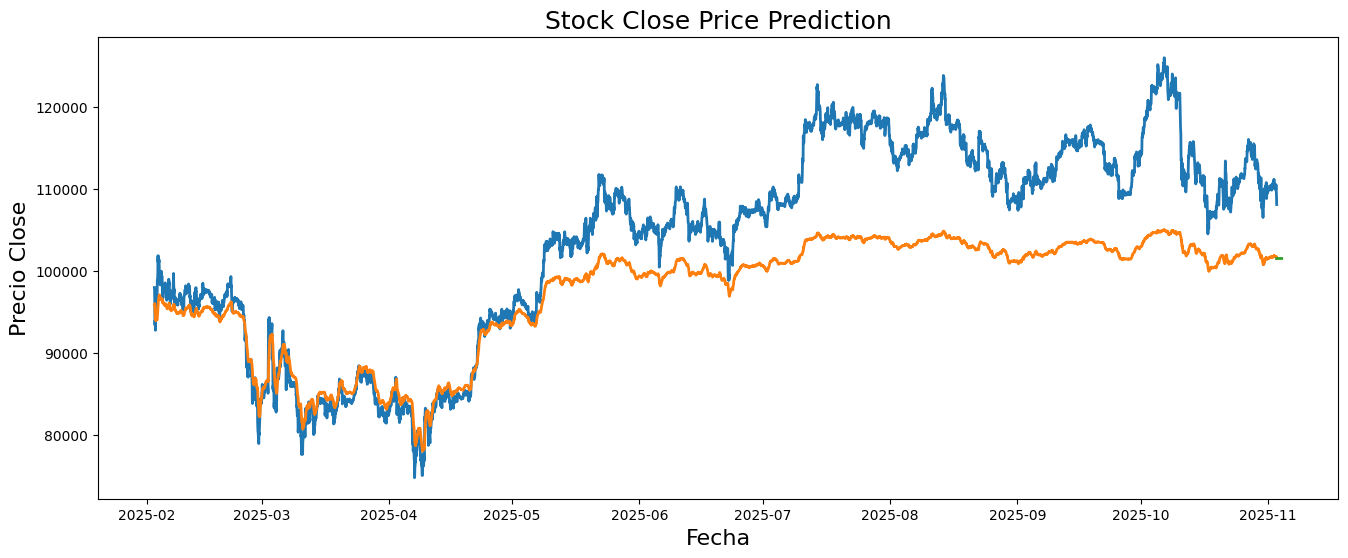

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Stock Close Price Prediction', fontsize=18)
plt.xlabel('Fecha', fontsize=16)
plt.ylabel('Precio Close', fontsize=16)
plt.plot(test.index, test['close'], linewidth=2)
plt.plot(test.index, test['Predictions'], linewidth=2)
plt.plot(df_result.index, df_result['Forecasted'], linewidth=2)